In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/used_cars.csv")

In [3]:
df.head()

,Unnamed: 0,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW


In [4]:
df.shape

(99187, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    99187 non-null  int64  
 1   model         99187 non-null  object 
 2   year          99187 non-null  int64  
 3   price         99187 non-null  int64  
 4   transmission  99187 non-null  object 
 5   mileage       99187 non-null  int64  
 6   fuelType      99187 non-null  object 
 7   tax           99187 non-null  int64  
 8   mpg           99187 non-null  float64
 9   engineSize    99187 non-null  float64
 10  Make          99187 non-null  object 
dtypes: float64(2), int64(5), object(4)
memory usage: 8.3+ MB


In [6]:
df.isnull().sum() / len(df) * 100

Unnamed: 0      0.0
model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
Make            0.0
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns=['Unnamed: 0'])
df.duplicated().sum()  

np.int64(1475)

In [9]:
df = df.drop_duplicates()
df.shape  

(97712, 10)

In [10]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW
5,T-Roc,2020,31895,Manual,10,Petrol,145,42.2,1.5,VW
6,T-Roc,2020,27895,Manual,10,Petrol,145,42.2,1.5,VW
7,T-Roc,2020,39495,Semi-Auto,10,Petrol,145,32.5,2.0,VW
8,T-Roc,2019,21995,Manual,10,Petrol,145,44.1,1.0,VW
9,T-Roc,2019,23285,Manual,10,Petrol,145,42.2,1.5,VW


In [12]:
df['model'] = df['model'].str.strip()

In [13]:
df[df['engineSize'] == 0]['fuelType'].value_counts()

fuelType
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

In [14]:
df[df['engineSize'] == 0][
    ['model', 'year', 'price', 'fuelType', 'engineSize', 'Make']
].head(20)


,model,year,price,fuelType,engineSize,Make
649,T-Roc,2019,22000,Petrol,0.0,VW
664,T-Roc,2018,23000,Diesel,0.0,VW
4734,Golf,2015,11800,Diesel,0.0,VW
4761,Golf,2019,18000,Petrol,0.0,VW
4768,Golf,2017,12600,Diesel,0.0,VW
6347,Passat,2018,17000,Petrol,0.0,VW
6351,Passat,2017,16000,Diesel,0.0,VW
6354,Passat,2018,19500,Petrol,0.0,VW
6356,Passat,2019,18500,Petrol,0.0,VW
11559,Tiguan,2017,19200,Diesel,0.0,VW


In [15]:
df[df['engineSize'] == 0]['fuelType'].value_counts()

fuelType
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

In [16]:
df[df['engineSize'] > 0]['fuelType'].value_counts()

fuelType
Petrol      53824
Diesel      40350
Hybrid       3021
Other         245
Electric        4
Name: count, dtype: int64

In [17]:
df['engineSize'] = df['engineSize'].replace(0, np.nan)
df['engineSize'] = df.groupby(['Make', 'model'])['engineSize'].transform(
    lambda x: x.fillna(x.median())
)
df['engineSize'] = df['engineSize'].fillna(df['engineSize'].median())

In [18]:
df['engineSize'].isnull().sum() 

np.int64(0)

In [19]:
df.describe()

,year,price,mileage,tax,mpg,engineSize,age
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066870,16773.487555,23219.475499,120.142408,55.205623,1.668847,8.933130
std,2.122993,9868.552222,21060.882301,63.357250,16.181659,0.552543,2.122993
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.600000,-34.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,56.000000


In [22]:
df[df['year'] >2026][['model', 'Make', 'year', 'price']]

,model,Make,year,price
77499,Fiesta,ford,2060,6495


In [21]:
df[df['year'] < 1990][['model', 'Make', 'year', 'price']]

,model,Make,year,price
25994,Zafira,vauxhall,1970,10495
53866,M Class,merc,1970,24999


In [23]:
df = df[(df['year'] >= 1990) & (df['year'] <= 2026)].copy()

In [25]:
CURRENT_YEAR = 2026
df['age'] = CURRENT_YEAR - df['year']

In [26]:
df.describe()

,year,price,mileage,tax,mpg,engineSize,age
count,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000
mean,2017.067394,16773.572823,23219.101884,120.138831,55.206047,1.668844,8.932606
std,2.107849,9868.593414,21060.893971,63.354366,16.181724,0.552544,2.107849
min,1996.000000,450.000000,1.000000,0.000000,0.300000,0.600000,6.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14470.000000,17682.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,30.000000


In [35]:
df.describe()

,year,price,mileage,tax,mpg,engineSize,age
count,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000
mean,2017.067394,16773.572823,23219.101884,120.138831,55.206047,1.668844,8.932606
std,2.107849,9868.593414,21060.893971,63.354366,16.181724,0.552544,2.107849
min,1996.000000,450.000000,1.000000,0.000000,0.300000,0.600000,6.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14470.000000,17682.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,30.000000


In [38]:


df[df['mpg'] > 150][['model', 'Make', 'mpg', 'fuelType']].head()


,model,Make,mpg,fuelType
1006,Golf,VW,166.2,Hybrid
1478,Golf,VW,188.3,Hybrid
1558,Golf,VW,166.2,Hybrid
1653,Golf,VW,156.9,Hybrid
1768,Golf,VW,166.2,Hybrid


In [39]:
print("High mpg (>150):", (df['mpg'] > 150).sum())
print("Low mpg (<15):", (df['mpg'] < 15).sum())
print("Total rows:", len(df))

High mpg (>150): 273
Low mpg (<15): 34
Total rows: 97709


In [40]:
df[df['mpg'] < 15].groupby(['Make', 'model', 'fuelType'])['mpg'].agg(['count', 'mean'])

count  mean
Make   model    fuelType             
BMW    3 Series Hybrid        8   8.8
       X3       Hybrid        6   5.5
VW     Golf SV  Petrol        1   0.3
hyundi Ioniq    Hybrid        4   1.1
merc   A Class  Hybrid        3   1.1
       G Class  Diesel        1  11.0
toyota C-HR     Petrol        1   6.0
       Hilux    Diesel       10   2.8

In [41]:
low_mpg = df[df['mpg'] < 15]
match_rate = (low_mpg['mpg'] == low_mpg['engineSize']).mean() * 100
print(f"{match_rate:.1f}% of low-mpg rows have mpg == engineSize")

0.0% of low-mpg rows have mpg == engineSize


In [42]:
df = df[df['mpg'] >= 15]
print("Rows remaining:", len(df))

Rows remaining: 97675


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize,age
count,97675.000000,97675.000000,97675.000000,97675.000000,97675.000000,97675.000000,97675.000000
mean,2017.066537,16767.050115,23225.786291,120.120195,55.223662,1.668734,8.933463
std,2.107689,9859.876571,21061.405182,63.348751,16.156864,0.552550,2.107689
min,1996.000000,450.000000,1.000000,0.000000,17.800000,0.600000,6.000000
25%,2016.000000,9999.000000,7683.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14460.000000,17695.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,30.000000


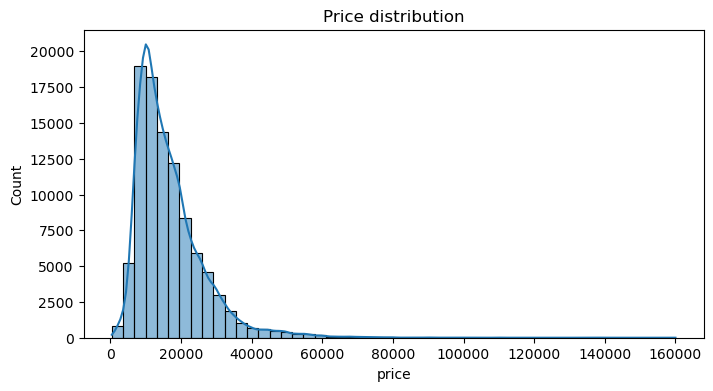

Skew: 2.363873355409517


In [28]:

plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price distribution')
plt.show()
print("Skew:", df['price'].skew())

In [ ]:
# The price distribution is strongly right-skewed (skewness ≈ 2.36).
# Most vehicles are concentrated in the lower-to-mid price range,
# while a small number of expensive vehicles create a long right tail.

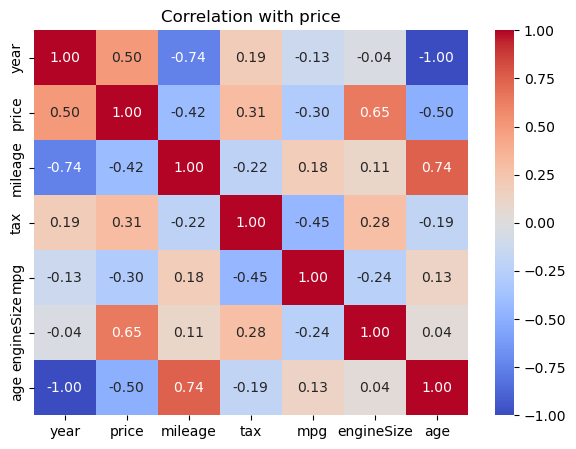

In [ ]:
# Correlation heatmap — numeric features only
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with price')
plt.show()

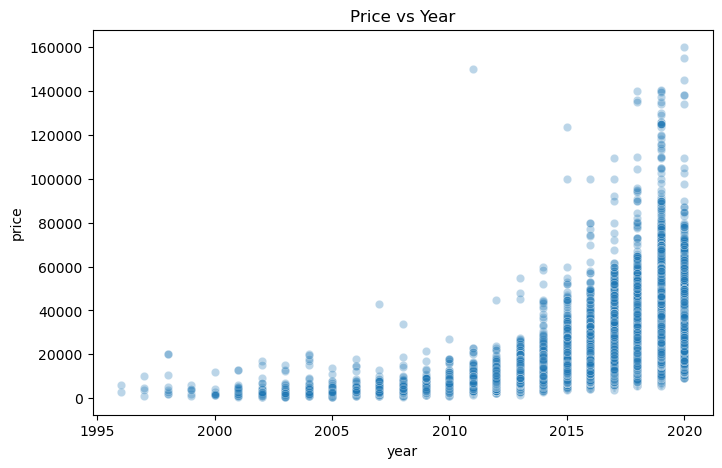

In [30]:
# Price vs Year (age) — expect a curve, not a straight line
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='year', y='price', alpha=0.3)
plt.title('Price vs Year')
plt.show()

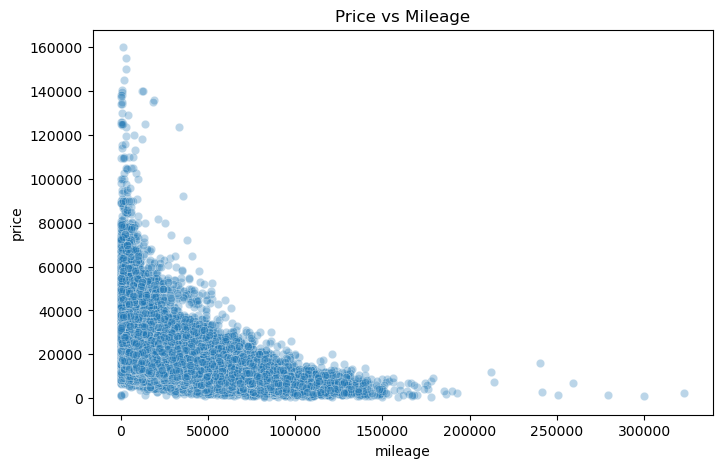

In [33]:
#  Price vs Mileage
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.3)
plt.title('Price vs Mileage')
plt.show()

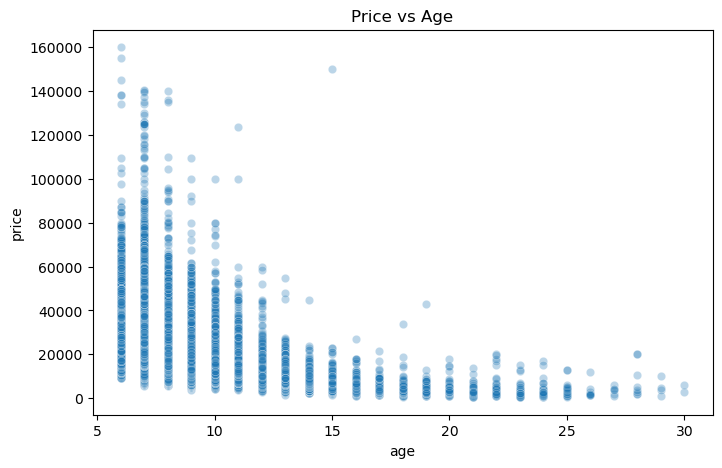

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='price', alpha=0.3)
plt.title('Price vs Age')
plt.show()

In [ ]:
# Price generally decreases as vehicle age increases. However, newer
# vehicles show a much wider range of prices, indicating that factors
# such as make, model, mileage, and engine size also strongly influence
# vehicle price.